# Project 7 -- [Katie] [Baumgartner]

TA Help: N/A

Collaboration: N/A

Internet Resources: N/A

ChatGPT, Gemini, Claude, etc: N/A

## Question 1

In [1]:
youtubers <- read.csv('/anvil/projects/tdm/data/youtube/most_subscribed_youtube_channels.csv')

In [2]:
youtubers$video.count2 <- as.numeric(gsub(",", "", youtubers$video.count))

In [3]:
category_counts <- tapply(youtubers$video.count2, youtubers$category, sum, na.rm = TRUE)

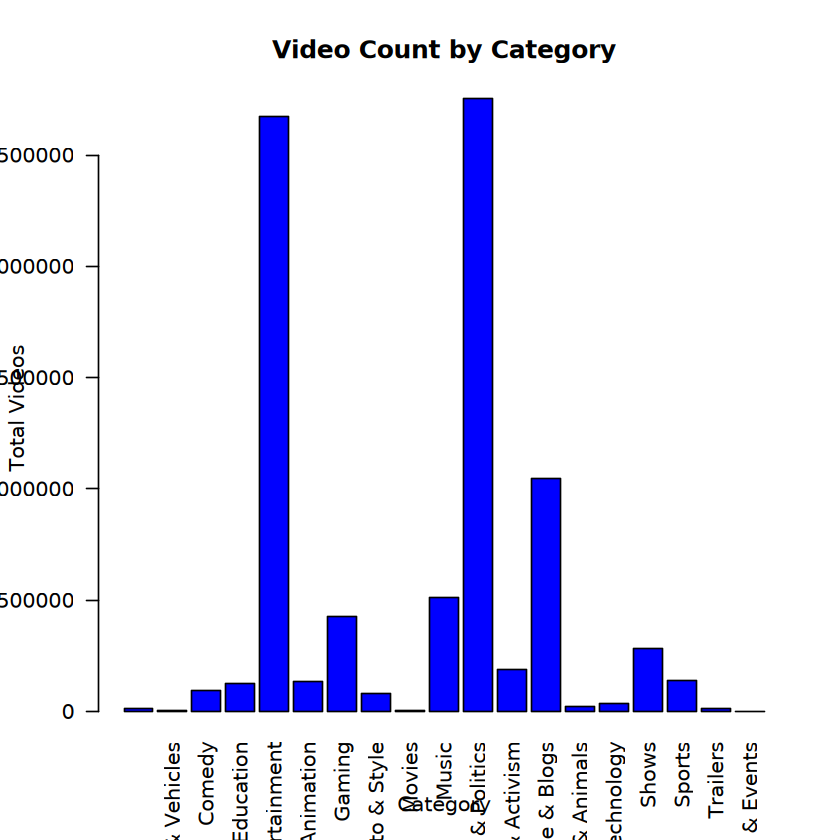

In [4]:
barplot(category_counts, main = "Video Count by Category", xlab = "Category", ylab = "Total Videos", las = 2, col = "blue")


In [5]:
gaming_music <- subset(youtubers, category %in% c("Gaming", "Music"))

In [6]:
gaming_music_counts <- tapply(gaming_music$video.count2, list(gaming_music$category, gaming_music$started), sum, na.rm = TRUE)

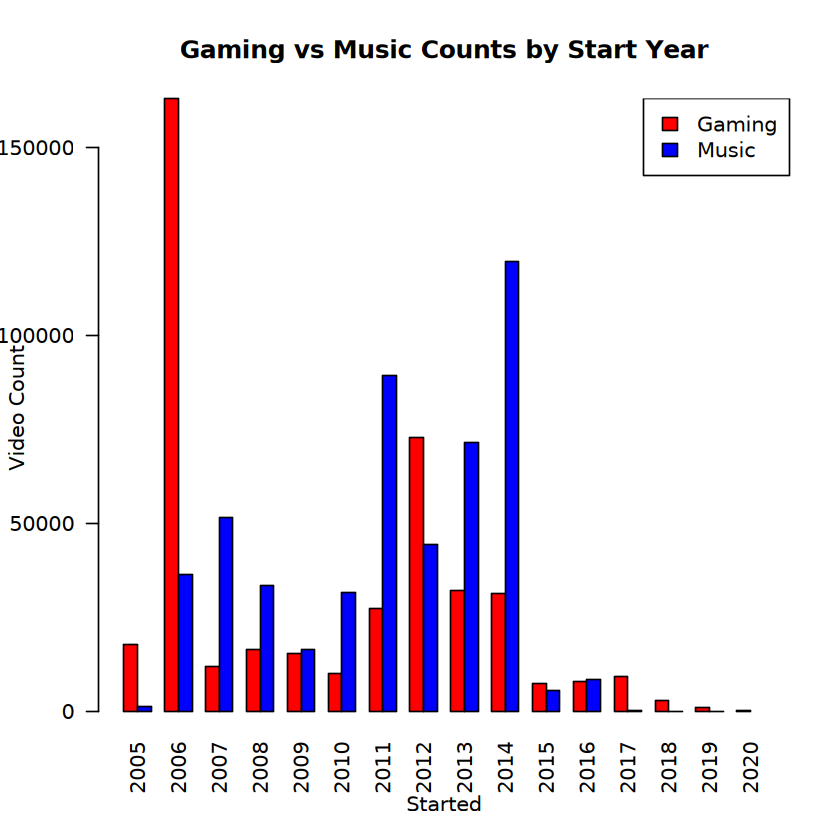

In [7]:
barplot(gaming_music_counts, beside = TRUE, main = "Gaming vs Music Counts by Start Year", xlab = "Started", ylab = "Video Count", las = 2, col = c("red", "blue"))

legend("topright", legend = rownames(gaming_music_counts), fill = c("red", "blue"))

In [8]:
average_by_year <- tapply(youtubers$video.count2, youtubers$started, mean, na.rm = TRUE)
average_by_year

1970      2005      2006      2007      2008      2009      2010      2011 
  540.000 15480.409 16612.625 24476.800 14807.333 10564.381  9957.319  5772.118 
     2012      2013      2014      2015      2016      2017      2018      2019 
 7142.812  7368.140  8370.807  4237.699  2594.442  5168.783  6515.543  2673.560 
     2020      2021 
 1385.000   696.750

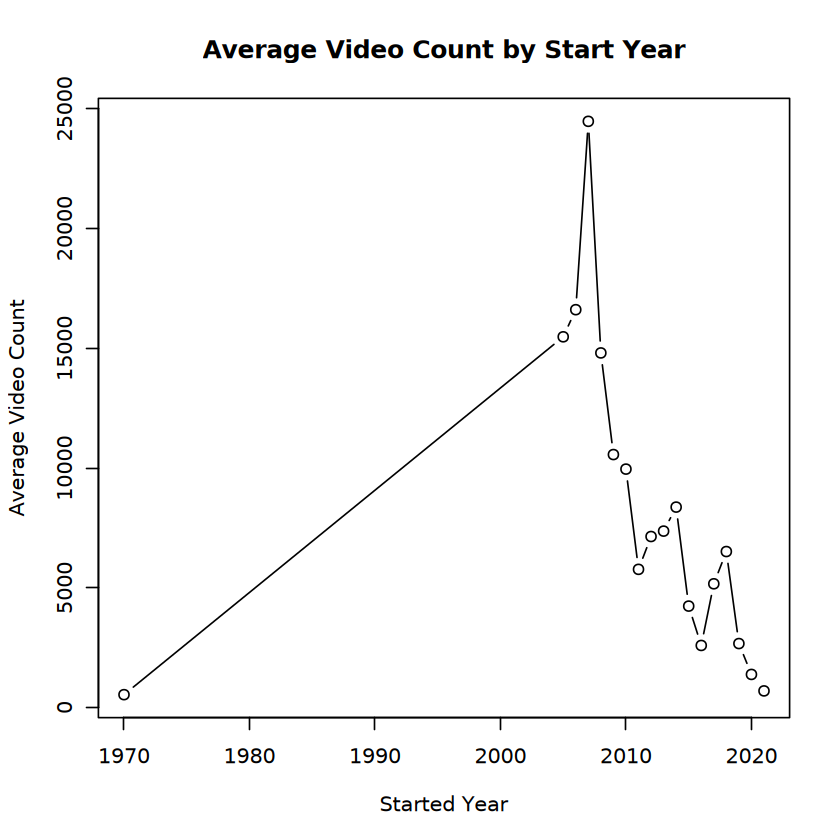

In [9]:
plot(names(average_by_year), average_by_year, type = "b", main = "Average Video Count by Start Year", xlab = "Started Year", ylab = "Average Video Count")

DELIVERABLES
1.1) news & policitcs
1.2) 2006
1.3) 

## Question 2

In [10]:
ts_songs <- read.csv2('/anvil/projects/tdm/data/spotify/taylor_swift_discography_updated.csv')

In [11]:
ts_songs <- ts_songs[ , !(names(ts_songs) %in% "track_lyrics")]

In [12]:
options(repr.matrix.max.cols=50, repr.matric.max.rows=200)

In [13]:
ts_songs$energy <- as.numeric(ts_songs$energy)

In [14]:
find_songs_with_energy <- function(input_df, threshold) 
{
  my_output <- input_df[input_df$energy >= threshold, ]
  return(my_output)
}

In [15]:
medianset <- median(ts_songs$energy, na.rm = TRUE)

In [16]:
high_energy <- find_songs_with_energy(ts_songs, medianset)

In [17]:
head(high_energy)

,X...ID,track_name,track_musical_genre,track_type,duration_ms,feature,track_videoclip,videoclip_views,spotify_streams,spotify_global_peak,album,track_number,album_musical_genre,album_type,release_date,album_physical_sales,track_theme,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
6,5,But Daddy I Love Him,Pop Rock,B-Side,340428,No,No,0,229410536,9,The Tortured Poets Department: The Anthology,6,Pop,Compilation/Deluxe,19/4/2024,0,Complicated love/Looking for love,spotify:track:4QMgEffJQuKtjCNvqfRZ0m,0.384,0.521,0.720,0.0,0.135,-7.684,0.104,79.943,0.438
8,7,Florida!!! (feat. Florence + The Machine),Indie Rock,B-Side,215463,Florence + The Machine,No,0,201272168,10,The Tortured Poets Department: The Anthology,8,Pop,Compilation/Deluxe,19/4/2024,0,Overcoming,spotify:track:5ExOm0dh4NyRyAdSAO9hyM,0.178,0.533,0.573,0.0,0.309,-7.123,0.138,150.088,0.398
13,12,I Can Do It With a Broken Heart,Electropop,Single,218004,No,No,0,439965329,5,The Tortured Poets Department: The Anthology,13,Pop,Compilation/Deluxe,19/4/2024,0,Overcoming,spotify:track:2fPvQfGQEZOKtJ9qXeL4x8,0.123,0.701,0.751,0.0,0.15,-8.39,0.0502,129.994,0.22
22,21,So High School,Pop Rock,B-Side,228800,No,No,0,169310310,29,The Tortured Poets Department: The Anthology,22,Pop,Compilation/Deluxe,19/4/2024,0,Fall in love,spotify:track:7Mts0OfPorF4iwOomvfqn1,0.0274,0.366,0.866,3.07e-06,0.106,-4.514,0.0466,176.07,0.293
27,26,Cassandra,Folk Pop,B-Side,240205,No,No,0,77285946,54,The Tortured Poets Department: The Anthology,27,Pop,Compilation/Deluxe,19/4/2024,0,Betrayal/Anger,spotify:track:0g4fMVo4JjwnIpTfFfLdxS,0.806,0.587,0.587,0.0,0.137,-9.879,0.0595,139.963,0.514
29,28,The Bolter,Country Pop,B-Side,238241,No,No,0,84927177,58,The Tortured Poets Department: The Anthology,29,Pop,Compilation/Deluxe,19/4/2024,0,Broken heart/Sadness,spotify:track:2913xXOVAIDAqxzV2g4VcU,0.638,0.455,0.586,0.0,0.131,-7.978,0.0492,183.694,0.481


In [18]:
high_energy_df <- find_songs_with_energy(ts_songs, medianset)

In [19]:
find_songs_by_album <- function(input_df, album) {
  my_output <- input_df[input_df$album == album, ]
  return(my_output)
}

In [20]:
tortured_poets_df <- find_songs_by_album(ts_songs,"The Tortured Poets Department: The Anthology")
nrow(tortured_poets_df)

[1] 31

DELIVERABLES
2.1) 0.95
2.2) 289
2.3) Above code

In [21]:
max_energy <- max(ts_songs$energy, na.rm = TRUE)
min_energy <- min(ts_songs$energy, na.rm = TRUE)

max_energy
min_energy

[1] 0.95

[1] 0.118

In [22]:
high_energy_df <- find_songs_with_energy(ts_songs, medianset)
nrow(high_energy_df)

[1] 289

## Question 3

In [23]:
ts_songs$numeric_streams <- as.numeric(ts_songs$spotify_streams)

Warning message:
"NAs introduced by coercion"


In [24]:
ts_songs[is.na(ts_songs$numeric_streams) & !is.na(ts_songs$spotify_streams), "spotify_streams"]

[1] "102.221.045"   "151.282.408"   "182.418.311"   "118.458.965"  
  [5] "88.205.974"    "101.800.187"   "77.667.730"    "75.816.684"   
  [9] "695.045.271"   "64.895.368"    "238.858.492"   "66.435.115"   
 [13] "86.966.267"    "65.608.381"    "67.947.237"    "106.436.747"  
 [17] "239.579.759"   "161.739.029"   "243.929.951"   "97.666.137"   
 [21] "327.037.965"   "57.248.658"    "102.221.045"   "151.282.408"  
 [25] "182.418.311"   "118.458.965"   "88.205.974"    "101.800.187"  
 [29] "77.667.730"    "75.816.684"    "695.045.271"   "64.895.368"   
 [33] "238.858.492"   "66.435.115"    "86.966.267"    "65.608.381"   
 [37] "67.947.237"    "106.436.747"   "239.579.759"   "161.739.029"  
 [41] "243.929.951"   "97.666.137"    "327.037.965"   "161.201.338"  
 [45] "111.149.636"   "180.262.965"   "95.341.130"    "99.582.468"   
 [49] "91.554.198"    "89.206.080"    "52.613.223"    "256.720.162"  
 [53] "116.688.485"   "44.117.403"    "72.179.901"    "72.138.383"   
 [57] "119.043.402"   "50.628.387"    "37.442.081"    "79.599.951"   
 [61] "75.501.290"    "233.537.019"   "77.280.948"    "85.579.355"   
 [65] "78.097.730"    "685.569.376"   "442.240.497"   "1.497.861.842"
 [69] "418.499.855"   "558.461.539"   "631.931.332"   "289.677.180"  
 [73] "379.998.152"   "511.571.475"   "263.703.912"   "737.680.743"  
 [77] "265.543.423"   "328.656.338"   "269.420.309"   "175.821.082"  
 [81] "176.277.983"   "148.303.282"   "118.355.491"   "257.804.372"  
 [85] "123.378.107"   "177.054.741"   "172.680.008"   "86.528.064"   
 [89] "685.569.376"   "442.240.497"   "1.497.861.842" "418.499.855"  
 [93] "558.461.539"   "631.931.332"   "289.677.180"   "379.998.152"  
 [97] "511.571.475"   "263.703.912"   "737.680.743"   "265.543.423"  
[101] "328.656.338"   "269.420.309"   "175.821.082"   "176.277.983"  
[105] "148.303.282"   "118.355.491"   "257.804.372"   "123.378.107"  
[109] "685.569.376"   "442.240.497"   "1.497.861.842" "418.499.855"  
[113] "558.461.539"   "631.931.332"   "289.677.180"   "379.998.152"  
[117] "511.571.475"   "263.703.912"   "737.680.743"   "265.543.423"  
[121] "328.656.338"   "119.887.717"   "276.457.730"   "107.168.641"  
[125] "331.115.790"   "249.885.271"   "265.698.765"   "89.369.701"   
[129] "315.588.138"   "86.371.415"    "108.741.392"   "84.058.644"   
[133] "93.349.578"    "74.802.137"    "144.156.621"   "68.667.868"   
[137] "98.591.643"    "69.027.319"    "108.053.400"   "56.901.647"   
[141] "51.126.307"    "42.569.086"    "139.140.884"   "209.924.444"  
[145] "118.151.653"   "185.024.136"   "206.457.482"   "90.351.777"   
[149] "135.457.781"   "166.946.516"   "810.542.565"   "276.701.835"  
[153] "97.490.294"    "714.184.368"   "86.368.640"    "94.810.816"   
[157] "619.978.693"   "64.707.634"    "55.729.532"    "70.295.638"   
[161] "397.666.679"   "107.430.716"   "50.543.835"    "43.303.976"   
[165] "54.359.548"    "55.397.353"    "50.407.943"    "39.608.696"   
[169] "35.505.550"    "69.531.567"    "51.835.918"    "109.187.805"  
[173] "358.733.130"   "57.957.104"    "76.512.224"    "68.743.624"   
[177] "53.973.432"    "814.114.651"   "588.394.719"   "279.044.935"  
[181] "260.055.245"   "297.807.837"   "266.696.518"   "180.744.525"  
[185] "168.010.057"   "174.430.479"   "211.246.717"   "180.507.774"  
[189] "190.498.817"   "205.207.043"   "119.250.347"   "208.212.731"  
[193] "315.084.417"   "105.356.578"   "814.114.651"   "588.394.719"  
[197] "279.044.935"   "260.055.245"   "297.807.837"   "266.696.518"  
[201] "180.744.525"   "168.010.057"   "174.430.479"   "211.246.717"  
[205] "180.507.774"   "190.498.817"   "205.207.043"   "119.250.347"  
[209] "208.212.731"   "552.789.777"   "1.240.468.789" "350.113.872"  
[213] "732.129.402"   "456.830.802"   "401.624.104"   "298.361.936"  
[217] "1.039.423.219" "375.813.987"   "389.023.820"   "351.443.321"  
[221] "206.915.468"   "179.012.062"   "339.198.629"   "202.357.820"  
[225] "180.324.854"   "147.911.887"   "17.256.353"    "22.319.608"   
[229] "13.10

In [25]:
ts_songs$cleaned_streams <- gsub("\\.", "", ts_songs$spotify_streams)

In [26]:
ts_songs$numeric_streams <- as.numeric(ts_songs$cleaned_streams)

In [27]:
find_songs_by_album <- function(input_df, album) {
  output <- input_df[input_df$album == album, ]
  return(output)
}

In [28]:
evermore <- find_songs_by_album(ts_songs, "evermore (deluxe version)")

In [29]:
evermore
nrow(evermore)

,X...ID,track_name,track_musical_genre,track_type,duration_ms,feature,track_videoclip,videoclip_views,spotify_streams,spotify_global_peak,album,track_number,album_musical_genre,album_type,release_date,album_physical_sales,track_theme,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,numeric_streams,cleaned_streams
,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>
225,224,willow,Indie Folk,Single,214706,No,No,0,814.114.651,1,evermore (deluxe version),1,Indie Folk,Compilation/Deluxe,7/1/2021,0,New love,spotify:track:2gVhfX2Gy1T9kDuS9azrF7,0.833,0.392,0.574,0.00179,0.145,-9.195,0.17,81.112,0.529,814114651,814114651
226,225,champagne problems,Indie Folk,B-Side,244000,No,No,0,588.394.719,10,evermore (deluxe version),2,Indie Folk,Compilation/Deluxe,7/1/2021,0,Broken heart/Sadness,spotify:track:1gcyHQpBQ1lfXGdhZmWrHP,0.92,0.462,0.240,0.0,0.113,-12.077,0.0377,171.319,0.32,588394719,588394719
227,226,gold rush,Indie Pop,B-Side,185320,No,No,0,279.044.935,19,evermore (deluxe version),3,Indie Folk,Compilation/Deluxe,7/1/2021,0,Complicated love/Looking for love,spotify:track:3Dby3p1m6IOZn2gIIqECgK,0.83,0.512,0.462,0.166,0.121,-10.491,0.0408,112.05,0.353,279044935,279044935
228,227,tis the damn season,Indie Folk,B-Side,229840,No,No,0,260.055.245,6,evermore (deluxe version),4,Indie Folk,Compilation/Deluxe,7/1/2021,0,Complicated love/Looking for love,spotify:track:6sQckd3Z8NPxVVKUnavY1F,0.735,0.575,0.434,6.59e-05,0.105,-8.193,0.0312,145.916,0.348,260055245,260055245
229,228,tolerate it,Indie Folk,B-Side,245440,No,No,0,297.807.837,24,evermore (deluxe version),5,Indie Folk,Compilation/Deluxe,7/1/2021,0,Broken heart/Sadness,spotify:track:6lCvK2AR2uOKkVFCVlAzzm,0.878,0.316,0.361,2.67e-05,0.0797,-10.381,0.0488,74.952,0.221,297807837,297807837
230,229,"no body, no crime (feat. HAIM)",Indie Rock,Single,215626,HAIM,No,0,266.696.518,5,evermore (deluxe version),6,Indie Folk,Compilation/Deluxe,7/1/2021,0,Betrayal/Anger,spotify:track:6uwfVkaOM1mcMkFmSn35ix,0.418,0.546,0.613,0.0,0.103,-7.589,0.0264,79.015,0.535,266696518,266696518
231,230,happiness,Indie Folk,B-Side,315146,No,No,0,180.744.525,28,evermore (deluxe version),7,Indie Folk,Compilation/Deluxe,7/1/2021,0,Nostalgia,spotify:track:55Vf4bimc1Rtfg0PAQRAo2,0.87,0.559,0.334,0.0,0.114,-10.733,0.0376,122.079,0.211,180744525,180744525
232,231,dorothea,Indie Folk,B-Side,225880,No,No,0,168.010.057,38,evermore (deluxe version),8,Indie Folk,Compilation/Deluxe,7/1/2021,0,Friendship,spotify:track:66tOfHVH3aUrscg8vExRV4,0.696,0.605,0.488,0.0,0.129,-8.322,0.0264,119.966,0.354,168010057,168010057
233,232,coney island (feat. The National),Indie Folk,Single,275320,The National,No,0,174.430.479,39,evermore (deluxe version),9,Indie Folk,Compilation/Deluxe,7/1/2021,0,Broken heart/Sadness,spotify:track:2awNGIJHodfLZSClB3PYhz,0.819,0.537,0.537,0.000904,0.142,-11.266,0.0617,107.895,0.292,174430479,174430479


[1] 17

In [30]:
dim(evermore)

[1] 17 29

DELIVERABLES
3.1) Because of the spare "." in the numeric values. It was converted to NA.
3.2) 17

## Question 4

In [31]:
find_songs_by_album <- function(input_df, album) 
{
  output <- input_df[input_df$album == album, ]
  return(output)
}

In [32]:
ts_1989 <- find_songs_by_album(ts_songs, "1989 (Taylor\'s Version) [Deluxe]")

In [33]:
nrow(ts_1989)

[1] 22

In [34]:
ts_songs$duration_sec <- ts_songs$duration_ms / 1000
ts_songs$duration_min <- ts_songs$duration_sec / 60

In [35]:
convert_duration <- function(df) 
{
  df$duration_sec <- df$duration_ms / 1000
  df$duration_min <- df$duration_sec / 60 
  return(df)
}

In [36]:
ts_1989 <- convert_duration(ts_1989)

In [37]:
head(ts_1989[, c("track_name", "duration_ms", "duration_sec", "duration_min")])

,track_name,duration_ms,duration_sec,duration_min
,<chr>,<int>,<dbl>,<dbl>
48,Welcome To New York (Taylor's Version),212600,212.600,3.543333
49,Blank Space (Taylor's Version),231833,231.833,3.863883
50,Style (Taylor's Version),231000,231.000,3.850000
51,Out Of The Woods (Taylor's Version),235800,235.800,3.930000
52,All You Had To Do Was Stay (Taylor's Version),193289,193.289,3.221483
53,Shake It Off (Taylor's Version),219209,219.209,3.653483


In [38]:
head(ts_1989)

,X...ID,track_name,track_musical_genre,track_type,duration_ms,feature,track_videoclip,videoclip_views,spotify_streams,spotify_global_peak,album,track_number,album_musical_genre,album_type,release_date,album_physical_sales,track_theme,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,numeric_streams,cleaned_streams,duration_sec,duration_min
,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>
48,47,Welcome To New York (Taylor's Version),Dance Pop,B-Side,212600,No,No,0,102.221.045,6,1989 (Taylor's Version) [Deluxe],1,Pop,Compilation/Deluxe,27/10/2023,0,Happiness,spotify:track:4WUepByoeqcedHoYhSNHRt,0.00942,0.757,0.610,3.66e-05,0.367,-4.84,0.0327,116.998,0.685,102221045,102221045,212.600,3.543333
49,48,Blank Space (Taylor's Version),Electropop,B-Side,231833,No,No,0,151.282.408,3,1989 (Taylor's Version) [Deluxe],2,Pop,Compilation/Deluxe,27/10/2023,0,New love,spotify:track:0108kcWLnn2HlH2kedi1gn,0.0885,0.733,0.733,0.0,0.168,-5.376,0.067,96.057,0.701,151282408,151282408,231.833,3.863883
50,49,Style (Taylor's Version),Synth Pop,B-Side,231000,No,No,0,182.418.311,1,1989 (Taylor's Version) [Deluxe],3,Pop,Compilation/Deluxe,27/10/2023,0,New love,spotify:track:3Vpk1hfMAQme8VJ0SNRSkd,0.000421,0.511,0.822,0.0197,0.0899,-4.785,0.0397,94.868,0.305,182418311,182418311,231.000,3.850000
51,50,Out Of The Woods (Taylor's Version),Synth Pop,B-Side,235800,No,No,0,118.458.965,8,1989 (Taylor's Version) [Deluxe],4,Pop,Compilation/Deluxe,27/10/2023,0,Complicated love/Losing love,spotify:track:1OcSfkeCg9hRC2sFKB4IMJ,0.000537,0.545,0.885,5.59e-05,0.385,-5.968,0.0447,92.021,0.206,118458965,118458965,235.800,3.930000
52,51,All You Had To Do Was Stay (Taylor's Version),Synth Pop,B-Side,193289,No,No,0,88.205.974,10,1989 (Taylor's Version) [Deluxe],5,Pop,Compilation/Deluxe,27/10/2023,0,Broken heart/Anger,spotify:track:2k0ZEeAqzvYMcx9Qt5aClQ,0.000656,0.588,0.721,0.0,0.131,-5.579,0.0317,96.997,0.52,88205974,88205974,193.289,3.221483
53,52,Shake It Off (Taylor's Version),Dance Pop,B-Side,219209,No,No,0,101.800.187,11,1989 (Taylor's Version) [Deluxe],6,Pop,Compilation/Deluxe,27/10/2023,0,Happiness,spotify:track:50yNTF0Od55qnHLxYsA5Pw,0.0121,0.636,0.808,2.18e-05,0.359,-5.693,0.0729,160.058,0.917,101800187,101800187,219.209,3.653483


DELIVERABLES
4.1) Above code
4.2) Above code

## Question 5

In [39]:
youtubers$subscribers2 <- gsub(",", "", youtubers$subscribers)
youtubers$subscribers2 <- as.numeric(youtubers$subscribers2)

In [40]:
head(youtubers[, c("subscribers", "subscribers2")])

,subscribers,subscribers2
,<chr>,<dbl>
1,"222,000,000",2.22e+08
2,"154,000,000",1.54e+08
3,"140,000,000",1.40e+08
4,"139,000,000",1.39e+08
5,"116,000,000",1.16e+08
6,"111,000,000",1.11e+08


In [41]:
find_top_channel <- function(df, genre) 
{
  genre_rows <- df[df$category == genre, ]
  max_index <- which.max(genre_rows$subscribers2)
  return(genre_rows[max_index, ])
}


In [42]:
find_top_channel(youtubers, "Gaming")

,rank,Youtuber,subscribers,video.views,video.count,category,started,video.count2,subscribers2
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>
6,6,PewDiePie,"111,000,000","28,469,458,228","4,497",Gaming,2010,4497,1.11e+08


In [43]:
find_top_channel(youtubers, "Education")

,rank,Youtuber,subscribers,video.views,video.count,category,started,video.count2,subscribers2
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>
3,3,Cocomelon - Nursery Rhymes,"140,000,000","135,481,339,848",786,Education,2006,786,1.4e+08


DELIVERABLES
5.1) Above code
5.2) Education; Cocomelon
5.3) The subscriber counts and rankings don't match today's real youtubenrankings, becuase this dataset is several years old.

## Pledge

By submitting this work I hereby pledge that this is my own, personal work. I've acknowledged in the designated place at the top of this file all sources that I used to complete said work, including but not limited to: online resources, books, and electronic communications. I've noted all collaboration with fellow students and/or TA's. I did not copy or plagiarize another's work.

> As a Boilermaker pursuing academic excellence, I pledge to be honest and true in all that I do. Accountable together – We are Purdue.

https://www.purdue.edu/odos/osrr/honor-pledge/
